
# Задачі кластеризації та класифікації


<h2>Мета</h2>

Ознайомитись з різновидами моделей для задач кластеризації та класифікації, а також методами побудови та оцінки цих моделей. Після завершення цієї лабораторної роботи ви зможете:

* Використовувати прості моделі для задач кластеризації та класифікації
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Виконайте кластеризацію по ВВП на душу населення та щільності населення.
2. Використайте метод ліктя для підбору оптимальної кількості кластерів.
3. Визначіть, який регіон домінує в кожному з кластерів.
4. Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).
5. Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Виконайте кластеризацію по ВВП на душу населення та щільності населення. </p>
</div>


Зчитую дані з файлу у датафрейм


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv('data/clean_data.csv')
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


Виділяю параметри для кластеризації

In [30]:
cluster_features = df[['GDP per capita', 'Density']]
cluster_scaler = StandardScaler()
cluster_features_scaled = cluster_scaler.fit_transform(cluster_features)

cluster_features.describe()

,GDP per capita,Density
count,217.000000,217.000000
mean,12997.297937,429.949541
std,17212.901697,2012.114136
min,285.727442,0.006594
25%,2175.673442,35.184097
50%,6049.232578,91.797365
75%,14900.778900,221.344014
max,100738.684200,20203.531353


Будую модель методом k середніх з кількістю кластерів 8

In [31]:
kmeans8 = KMeans(
    init='k-means++',
    n_clusters=8,
    n_init=20,
    max_iter=300,
    random_state=42,
)

kmeans8.fit(cluster_features_scaled)

,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 2)","[[-0.

<p>Отримані центри кластерів:</p>


In [32]:
centers8 = pd.DataFrame(
    cluster_scaler.inverse_transform(kmeans8.cluster_centers_),
    columns=cluster_features.columns,
)
centers8.index.name = 'Cluster'
centers8.round(2)

,GDP per capita,Density
Cluster,,
0,3689.12,140.88
1,14900.78,19249.50
2,36237.83,207.78
3,83831.44,147.14
4,48351.74,7223.66
5,15595.82,351.10
6,54877.86,115.28
7,74017.18,20203.53


<p>Масив із номерами кластерів для кожного рядка даних:</p>


In [33]:
kmeans8.labels_

array([0, 0, 0, 5, 2, 0, 5, 5, 0, 0, 6, 2, 0, 2, 5, 0, 5, 0, 2, 0, 0, 6,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 5, 5, 0, 0, 0,
       0, 0, 5, 0, 5, 0, 0, 5, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 5, 0,
       2, 2, 0, 0, 0, 0, 2, 0, 5, 5, 5, 5, 2, 0, 0, 0, 0, 0, 0, 4, 5, 6,
       0, 0, 0, 0, 6, 5, 2, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 5, 0,
       0, 0, 0, 5, 5, 3, 7, 0, 0, 0, 0, 5, 0, 5, 0, 0, 5, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 5, 3, 5, 0, 5, 5, 0, 0, 0,
       0, 5, 5, 2, 6, 0, 0, 0, 0, 6, 0, 5, 0, 0, 5, 0, 4, 0, 5, 5, 0, 0,
       0, 0, 2, 0, 5, 0, 0, 0, 0, 0, 0, 6, 3, 0, 0, 0, 0, 0, 0, 0, 5, 0,
       5, 0, 0, 0, 0, 0, 2, 2, 6, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

<p>Візуалізую отримані кластери:</p>


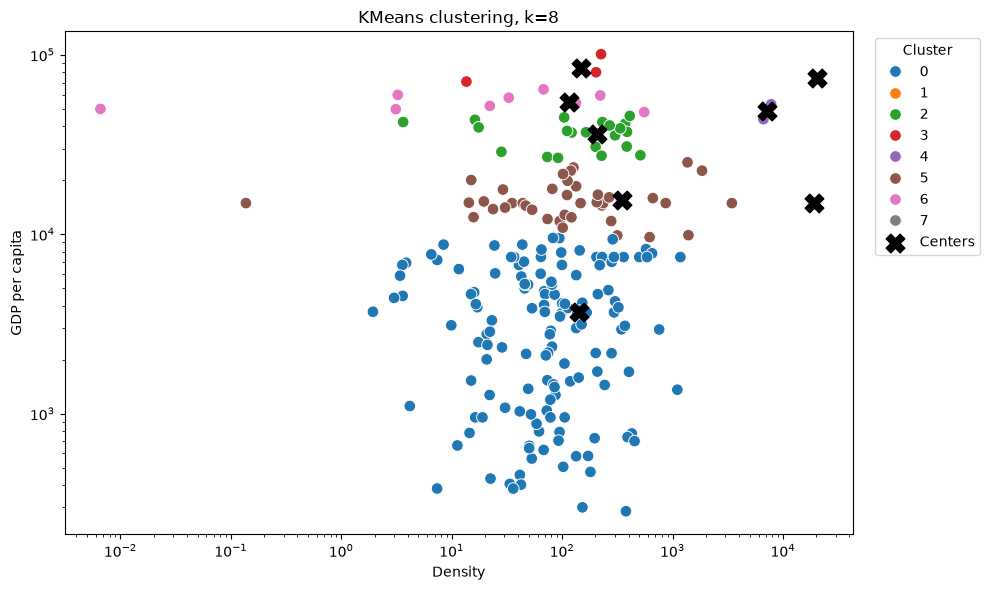

In [34]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Density',
    y='GDP per capita',
    hue=kmeans8.labels_,
    palette='tab10',
    s=70,
)
plt.scatter(
    centers8['Density'],
    centers8['GDP per capita'],
    c='black',
    marker='X',
    s=180,
    label='Centers',
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Density')
plt.ylabel('GDP per capita')
plt.title('KMeans clustering, k=8')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Використайте метод ліктя для підбору оптимальної кількості кластерів.</p>
</div>


Визначаю оптимальну кількість кластерів. Скористаюсь методом "ліктя". Для цього ініціалізую алгоритм k середніх кількістю кластерів від 1 до 10 і для кожної моделі рахую суму квадратів похибок (евклідових відстаней точок кластерів від відповідних центрів):

In [35]:
kmeans_kwargs = {
    'init': 'k-means++',
    'n_init': 20,
    'max_iter': 300,
    'random_state': 42,
}

sse = []
silhouette_coefficients = []
max_clusters = 10

for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(cluster_features_scaled)
    sse.append(kmeans.inertia_)
    if k > 1:
        silhouette_coefficients.append(silhouette_score(cluster_features_scaled, kmeans.labels_))

elbow_results = pd.DataFrame({
    'k': range(1, max_clusters + 1),
    'SSE': sse,
    'Silhouette': [np.nan] + silhouette_coefficients,
})
elbow_results.round(4)

,k,SSE,Silhouette
0,1,434.0000,NaN
1,2,240.7107,0.8977
2,3,84.2926,0.7520
3,4,61.0172,0.7601
4,5,40.1598,0.6338
5,6,26.8736,0.6299
6,7,20.8357,0.6257
7,8,16.2085,0.6036
8,9,12.8738,0.5670
9,10,10.1557,0.5287


<p>Візуалізую отримані результати:</p>


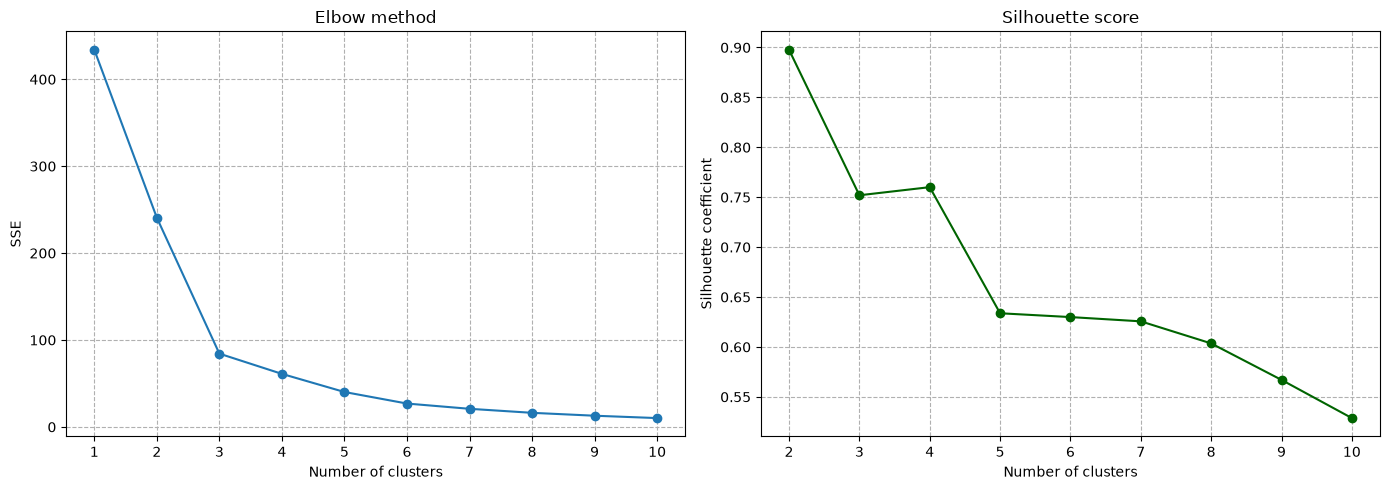

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, max_clusters + 1), sse, marker='o')
axes[0].set_xticks(range(1, max_clusters + 1))
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('SSE')
axes[0].set_title('Elbow method')
axes[0].grid(linestyle='--')

axes[1].plot(range(2, max_clusters + 1), silhouette_coefficients, marker='o', color='darkgreen')
axes[1].set_xticks(range(2, max_clusters + 1))
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette coefficient')
axes[1].set_title('Silhouette score')
axes[1].grid(linestyle='--')

plt.tight_layout()
plt.show()

<p>Оптимальна кількість кластерів за методом ліктя дорівнює <b>3</b>: після цього значення SSE зменшується вже значно повільніше.</p>
<p>Візуалізую для оптимальної кількості кластерів:</p>


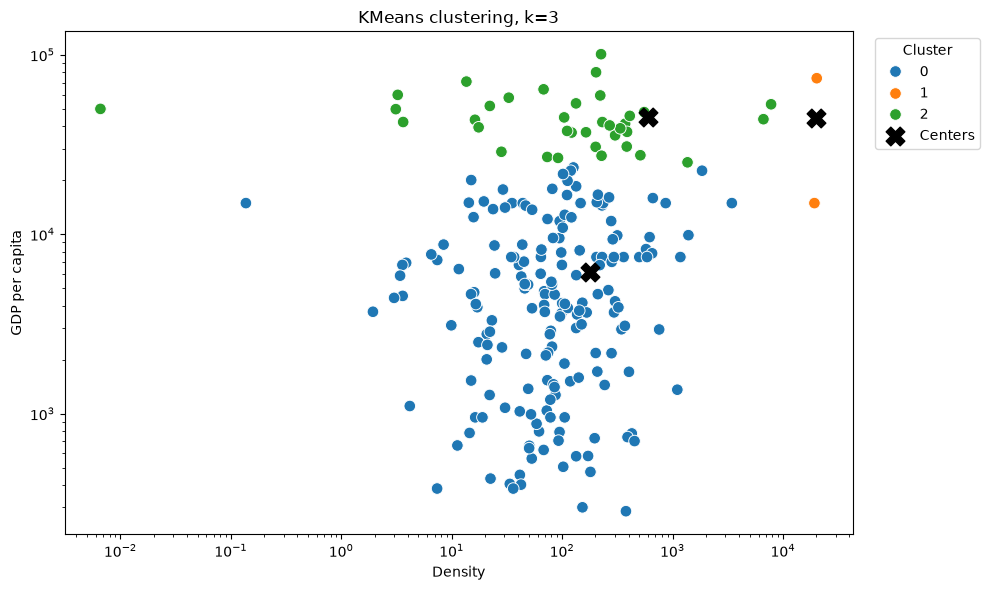

,GDP per capita,Density
Cluster,,
0,6163.45,179.84
1,44458.98,19726.52
2,45228.84,601.53


In [37]:
optimal_k = 3
optimal_kmeans = KMeans(n_clusters=optimal_k, **kmeans_kwargs)
optimal_kmeans.fit(cluster_features_scaled)

optimal_centers = pd.DataFrame(
    cluster_scaler.inverse_transform(optimal_kmeans.cluster_centers_),
    columns=cluster_features.columns,
)
optimal_centers.index.name = 'Cluster'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Density',
    y='GDP per capita',
    hue=optimal_kmeans.labels_,
    palette='tab10',
    s=70,
)
plt.scatter(
    optimal_centers['Density'],
    optimal_centers['GDP per capita'],
    c='black',
    marker='X',
    s=180,
    label='Centers',
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Density')
plt.ylabel('GDP per capita')
plt.title('KMeans clustering, k=3')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

optimal_centers.round(2)

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Визначіть, який регіон домінує в кожному з кластерів.</p>
</div>


Додаю мітки кластерів в датафрейм

In [38]:
df_clustered = df.copy()
df_clustered['Cluster'] = optimal_kmeans.labels_
df_clustered.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Density,Cluster
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405,0
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296,0
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902,0
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000,0
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660,2


Визначаю домінуючий регіон для кожного кластера

In [39]:
cluster_region_counts = pd.crosstab(df_clustered['Cluster'], df_clustered['Region'])
dominant_region_summary = pd.DataFrame({
    'Dominant region': cluster_region_counts.idxmax(axis=1),
    'Countries in dominant region': cluster_region_counts.max(axis=1),
    'Cluster size': cluster_region_counts.sum(axis=1),
})

display(cluster_region_counts)
dominant_region_summary

Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
Cluster,,,,,,,
0,28,39,40,16,0,8,48
1,1,1,0,0,0,0,0
2,8,18,2,5,3,0,0


,Dominant region,Countries in dominant region,Cluster size
Cluster,,,
0,Sub-Saharan Africa,48,179
1,East Asia & Pacific,1,2
2,Europe & Central Asia,18,36


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).</p>
</div>


 Обираю потрібні ознаки:


In [40]:
classification_features = ['GDP per capita', 'Population', 'CO2 emission', 'Area']
target = 'Region'

X = df[classification_features]
y = df[target]

X.head()

,GDP per capita,Population,CO2 emission,Area
0,561.778746,34656032.0,9809.225,652860.0
1,4124.982390,2876101.0,5716.853,28750.0
2,3916.881571,40606052.0,145400.217,2381740.0
3,11834.745230,55599.0,6501.591,200.0
4,36988.622030,77281.0,462.042,470.0


 Розділяю датасет на навчальну і тестову вибірки за допомогою функції <code>train_test_split()</code>:


In [41]:

df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[target],
)

df_train.shape, df_test.shape


((173, 7), (44, 7))

<p>Розміщую цільові дані - Region -  в окремому датафреймі:</p>

In [42]:
x_train = df_train[classification_features]
y_train = df_train[target]

x_test = df_test[classification_features]
y_test = df_test[target]

<h3>Навчання та тестування моделей:</h3>

Для навчання були обрані наступні методи:

- k-nearest neighbors;
- support vector machine;
- decision tree;
- random forest;
- extra trees.


 <h3>Метод 1</h3>


Будую модель


In [43]:
KNN_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=7),
)
KNN_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](7,)","['East Asia & Pacific','Europe & Central Asia','Latin America & Caribbean', ...,'North America','South Asia','Sub-Saharan Africa']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['GDP per capita','Population','CO2 emission','Area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Оцінюю точність

In [44]:
classification_results = {}

def evaluate_classifier(name, model):
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    classification_results[name] = accuracy
    print(f'{name} accuracy = {accuracy:.4f}')
    print(classification_report(y_test, y_pred, zero_division=0))
    return y_pred

knn_pred = evaluate_classifier('KNN', KNN_model)

KNN accuracy = 0.4545
                            precision    recall  f1-score   support

       East Asia & Pacific       0.30      0.43      0.35         7
     Europe & Central Asia       0.47      0.58      0.52        12
 Latin America & Caribbean       0.25      0.25      0.25         8
Middle East & North Africa       0.00      0.00      0.00         4
             North America       0.00      0.00      0.00         1
                South Asia       0.00      0.00      0.00         2
        Sub-Saharan Africa       0.80      0.80      0.80        10

                  accuracy                           0.45        44
                 macro avg       0.26      0.29      0.27        44
              weighted avg       0.40      0.45      0.42        44



 <h3>Support Vector Machine</h3>


Будую модель


In [45]:
SVC_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
)
SVC_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](7,)","['East Asia & Pacific','Europe & Central Asia','Latin America & Caribbean', ...,'North America','South Asia','Sub-Saharan Africa']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['GDP per capita','Population','CO2 emission','Area']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Оцінюю точність

In [46]:
svc_pred = evaluate_classifier('SVC', SVC_model)

SVC accuracy = 0.4545
                            precision    recall  f1-score   support

       East Asia & Pacific       0.00      0.00      0.00         7
     Europe & Central Asia       0.56      0.75      0.64        12
 Latin America & Caribbean       0.22      0.25      0.24         8
Middle East & North Africa       0.00      0.00      0.00         4
             North America       1.00      1.00      1.00         1
                South Asia       0.00      0.00      0.00         2
        Sub-Saharan Africa       0.57      0.80      0.67        10

                  accuracy                           0.45        44
                 macro avg       0.34      0.40      0.36        44
              weighted avg       0.35      0.45      0.39        44



 <h3>Decision Tree</h3>


Будую модель


In [47]:
decision_tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree_model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Оцінюю точність

In [48]:
decision_tree_pred = evaluate_classifier('Decision Tree', decision_tree_model)

Decision Tree accuracy = 0.4773
                            precision    recall  f1-score   support

       East Asia & Pacific       0.23      0.43      0.30         7
     Europe & Central Asia       0.50      0.50      0.50        12
 Latin America & Caribbean       0.43      0.38      0.40         8
Middle East & North Africa       0.25      0.25      0.25         4
             North America       0.00      0.00      0.00         1
                South Asia       1.00      0.50      0.67         2
        Sub-Saharan Africa       1.00      0.70      0.82        10

                  accuracy                           0.48        44
                 macro avg       0.49      0.39      0.42        44
              weighted avg       0.55      0.48      0.50        44



 <h3>Random Forest</h3>


Будую модель


In [49]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced',
)
random_forest_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

Оцінюю точність

In [50]:
random_forest_pred = evaluate_classifier('Random Forest', random_forest_model)

Random Forest accuracy = 0.5227
                            precision    recall  f1-score   support

       East Asia & Pacific       0.38      0.43      0.40         7
     Europe & Central Asia       0.69      0.75      0.72        12
 Latin America & Caribbean       0.25      0.25      0.25         8
Middle East & North Africa       0.33      0.25      0.29         4
             North America       1.00      1.00      1.00         1
                South Asia       0.25      0.50      0.33         2
        Sub-Saharan Africa       0.86      0.60      0.71        10

                  accuracy                           0.52        44
                 macro avg       0.54      0.54      0.53        44
              weighted avg       0.55      0.52      0.53        44



 <h3>Extra Trees</h3>


Будую модель


In [51]:
extra_trees_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced',
)
extra_trees_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None,

Оцінюю точність

In [52]:
extra_trees_pred = evaluate_classifier('Extra Trees', extra_trees_model)

pd.Series(classification_results, name='Accuracy').sort_values(ascending=False).to_frame()

Extra Trees accuracy = 0.5455
                            precision    recall  f1-score   support

       East Asia & Pacific       0.29      0.29      0.29         7
     Europe & Central Asia       0.69      0.75      0.72        12
 Latin America & Caribbean       0.29      0.25      0.27         8
Middle East & North Africa       0.50      0.25      0.33         4
             North America       1.00      1.00      1.00         1
                South Asia       0.00      0.00      0.00         2
        Sub-Saharan Africa       0.69      0.90      0.78        10

                  accuracy                           0.55        44
                 macro avg       0.49      0.49      0.48        44
              weighted avg       0.51      0.55      0.52        44



,Accuracy
Extra Trees,0.545455
Random Forest,0.522727
Decision Tree,0.477273
KNN,0.454545
SVC,0.454545


<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>модель Extra Trees є найкращою</b> для цього розбиття даних: вона має найбільшу accuracy на тестовій вибірці.</p>


<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.</p>
</div>


<p>Виконую підбір параметра <code>max_depth</code> для моделі <code>ExtraTreesClassifier</code>.</p>
<p>Для цього ініціалізую алгоритм з <code>max_depth</code> від 1 до 20 і для кожної моделі рахую mean accuracy на тестовій вибірці:</p>


In [53]:
depth_values = range(1, 21)
extra_trees_depth_scores = []

for depth in depth_values:
    model = ExtraTreesClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        class_weight='balanced',
    )
    model.fit(x_train, y_train)
    extra_trees_depth_scores.append(model.score(x_test, y_test))

best_depth_index = int(np.argmax(extra_trees_depth_scores))
best_depth = list(depth_values)[best_depth_index]
best_depth_score = extra_trees_depth_scores[best_depth_index]

print(f'Best max_depth = {best_depth}')
print(f'Best accuracy = {best_depth_score:.4f}')

pd.DataFrame({
    'max_depth': list(depth_values),
    'accuracy': extra_trees_depth_scores,
}).round(4)

Best max_depth = 12
Best accuracy = 0.5682


,max_depth,accuracy
0,1,0.4773
1,2,0.4318
2,3,0.4773
3,4,0.5000
4,5,0.5000
5,6,0.5227
6,7,0.5227
7,8,0.5455
8,9,0.4773
9,10,0.5455


 Отримані показники якості візуалізую на графіку:


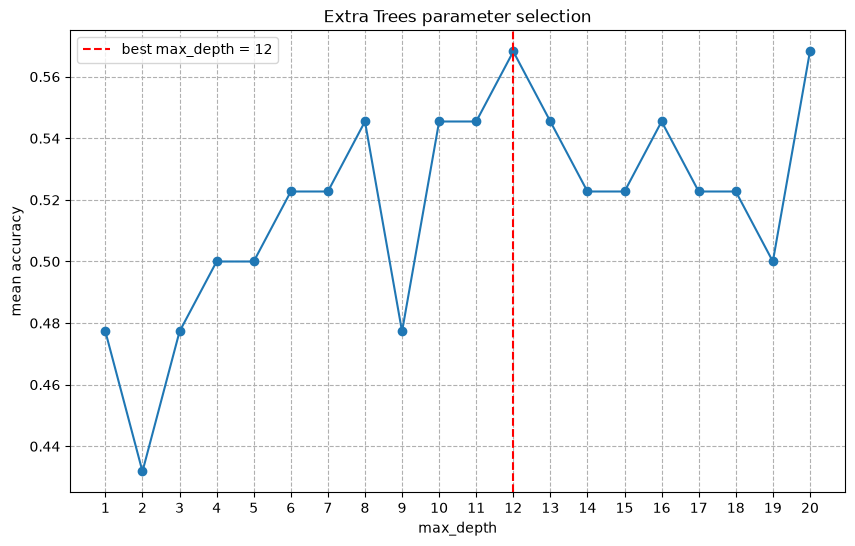

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(list(depth_values), extra_trees_depth_scores, marker='o')
plt.axvline(best_depth, color='red', linestyle='--', label=f'best max_depth = {best_depth}')
plt.xticks(list(depth_values))
plt.xlabel('max_depth')
plt.ylabel('mean accuracy')
plt.title('Extra Trees parameter selection')
plt.grid(linestyle='--')
plt.legend()
plt.show()

З графіку бачу, що найкраще значення параметра <code>max_depth</code> для цього розбиття починається з 12: accuracy досягає максимуму, а подальше збільшення глибини не дає стабільного покращення. Тому обираю <code>max_depth = 12</code>.


<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Використовуючи файл <a href="https://drive.google.com/file/d/1gxqzPQNlqrwrJI3zstMsvHQAbsdMPe-2/view?usp=drive_link" target="_blank">Data5.csv</a>:

1. Визначити кластер країн з найкращим розвитком (кластеризувати по Ie, Iec, Is; для k-середніх використати 4 кластера). Побудувати центри кластерів.
2. Провести кластеризацію по Сql, порахувати скільки країн потрапило в різні кластери, якщо порівнювати з п1.</p>
</div>


Згідно з методологією вимірювання сталого розвитку країн, сталий розвиток оцінюється за допомогою відповідного індексу у просторі трьох вимірів: економічного (Іес), екологічного (Іе) і соціально-інституціонального (Is). Цей індекс є вектором, норма якого визначає рівень сталого розвитку, а його просторове положення в системі координат (Iec,Ie,Is) характеризує міру «гармонійності» цього розвитку.

<details><summary>Натисніть тут, щоб побачити підказку до першого завдання</summary>

```python
# Зчитуємо заданий набір даних, зразу коригуючи
df = pd.read_csv(
    'Data5.csv', encoding='windows-1251', sep=';', decimal=','
).rename(columns={'Unnamed: 0': 'Country'})

df

```

</details>



In [55]:
development_df = pd.read_csv(
    'Data5.csv', encoding='windows-1251', sep=';', decimal=','
).rename(columns={'Unnamed: 0': 'Country'})

development_features = ['Ie', 'Iec', 'Is']
development_scaler = StandardScaler()
development_scaled = development_scaler.fit_transform(development_df[development_features])

development_kmeans = KMeans(n_clusters=4, **kmeans_kwargs)
development_kmeans.fit(development_scaled)

development_df['Development cluster'] = development_kmeans.labels_

development_centers = pd.DataFrame(
    development_scaler.inverse_transform(development_kmeans.cluster_centers_),
    columns=development_features,
)
development_centers['Mean index'] = development_centers[development_features].mean(axis=1)
development_centers.index.name = 'Cluster'

best_development_cluster = int(development_centers['Mean index'].idxmax())
print(f'Cluster with the best development: {best_development_cluster}')
print(f'Number of countries in this cluster: {(development_df["Development cluster"] == best_development_cluster).sum()}')

display(development_centers.round(4).sort_values('Mean index', ascending=False))
development_df.loc[
    development_df['Development cluster'] == best_development_cluster,
    ['Country', 'ISO', 'Cql', 'Ie', 'Iec', 'Is'],
].sort_values('Cql', ascending=False)

Cluster with the best development: 2
Number of countries in this cluster: 26


,Ie,Iec,Is,Mean index
Cluster,,,,
2,0.7677,0.6835,0.6471,0.6994
0,0.6483,0.5552,0.5579,0.5871
3,0.5688,0.4280,0.4754,0.4907
1,0.2793,0.3944,0.3990,0.3576


,Country,ISO,Cql,Ie,Iec,Is
5,Australia,AUS,1.457611,0.791517,0.721155,0.692414
120,Switzerland,CHE,1.454859,0.771155,0.770265,0.669772
125,United Kingdom,GBR,1.443573,0.809062,0.698265,0.679464
35,Denmark,DNK,1.441151,0.803673,0.679001,0.698137
47,Germany,DEU,1.436559,0.748135,0.767174,0.664004
112,Singapore,SGP,1.429509,0.792138,0.781236,0.624389
91,New Zealand,NZL,1.427049,0.812911,0.701622,0.654466
126,United States,USA,1.426584,0.758169,0.774111,0.643449
63,Japan,JPN,1.423174,0.718327,0.785976,0.656615
23,Canada,CAN,1.405515,0.764216,0.737761,0.637167


<details><summary>Натисніть тут, щоб побачити підказку до другого завдання</summary>

Номери кластерів для першого і другого методів кластеризації зовсім не обовязково співпадатимуть. Щоб знайти відповідність, подивіться в які кластери з другого методу потрапляють центри кластерів з першого.

Порахувати скільки країн потрапило в різні кластери можна з використанням матриці невідповідностей (як аргументи поставти номери кластерів для першого і другого методів кластеризації).

</details>

In [56]:
cql_scaler = StandardScaler()
cql_scaled = cql_scaler.fit_transform(development_df[['Cql']])

cql_kmeans = KMeans(n_clusters=4, **kmeans_kwargs)
cql_kmeans.fit(cql_scaled)

development_df['Cql cluster'] = cql_kmeans.labels_

cql_centers = pd.DataFrame(
    cql_scaler.inverse_transform(cql_kmeans.cluster_centers_),
    columns=['Cql center'],
)
cql_centers.index.name = 'Cql cluster'

comparison_matrix = pd.crosstab(
    development_df['Development cluster'],
    development_df['Cql cluster'],
)

# Порівнюю номери кластерів через середнє Cql у кластерах розвитку,
# бо KMeans може присвоїти однаковим за змістом групам різні номери.
development_cluster_cql_centers = development_df.groupby('Development cluster')[['Cql']].mean()
mapped_cql_clusters = cql_kmeans.predict(cql_scaler.transform(development_cluster_cql_centers))
cluster_mapping = {
    int(development_cluster): int(cql_cluster)
    for development_cluster, cql_cluster in zip(development_cluster_cql_centers.index, mapped_cql_clusters)
}

development_df['Mapped Cql cluster'] = development_df['Development cluster'].map(cluster_mapping)
development_df['Same cluster group'] = development_df['Mapped Cql cluster'] == development_df['Cql cluster']

different_clusters_count = int((~development_df['Same cluster group']).sum())
matching_clusters_count = int(development_df['Same cluster group'].sum())

print('Centers of Cql clusters:')
display(cql_centers.round(4).sort_values('Cql center', ascending=False))

print('Development clusters vs Cql clusters:')
display(comparison_matrix)

print(f'Development cluster to Cql cluster mapping: {cluster_mapping}')
print(f'Countries in matching clusters: {matching_clusters_count}')
print(f'Countries in different clusters: {different_clusters_count}')

Centers of Cql clusters:


,Cql center
Cql cluster,
1,1.3616
3,1.0655
0,0.7880
2,0.4738


Development clusters vs Cql clusters:


Cql cluster,0,1,2,3
Development cluster,,,,
0,0,3,0,31
1,3,0,27,0
2,0,26,0,0
3,37,0,1,4


Development cluster to Cql cluster mapping: {0: 3, 1: 2, 2: 1, 3: 0}
Countries in matching clusters: 121
Countries in different clusters: 11


<h2>Виконав студент групи ІП-45 <br> Янов Богдан</h2>
